# 🛍️ GlobalMart AI-Based Customer Journey Mapping
## Practical Implementation — AI for Marketing & Decision Making
### Astana IT University | School of Creative Industries

---

**Company:** GlobalMart — A fictional multinational retail chain operating across **5 regions**:
- 🌍 Central Asia (Astana, Almaty, Tashkent, Bishkek)
- 🌍 Europe (London, Berlin, Paris, Amsterdam, Warsaw)
- 🌍 MENA (Dubai, Riyadh, Cairo, Istanbul)
- 🌍 North America (New York, Toronto, Los Angeles, Chicago)
- 🌍 Southeast Asia (Singapore, Bangkok, Jakarta, Manila)

**Dataset Files (upload these to your environment):**
| File | Description | Rows |
|------|-------------|------|
| `customers.csv` | Customer demographics, region, segment | 5,000 |
| `transactions.csv` | Purchase history, revenue, channel | ~58,000 |
| `touchpoints.csv` | Journey stage interactions | ~40,000 |
| `reviews.csv` | Customer reviews with ratings | 3,000 |
| `churn_labels.csv` | Churn status per customer | 5,000 |

---


## 📦 0. Setup & Data Loading

In [ ]:
# ── Install / import all required libraries ─────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3d4166',
    'axes.labelcolor':  '#e0e0e0',
    'text.color':       '#e0e0e0',
    'xtick.color':      '#b0b0b0',
    'ytick.color':      '#b0b0b0',
    'grid.color':       '#2a2d3e',
    'grid.alpha':       0.5,
    'legend.facecolor': '#1a1d2e',
    'legend.edgecolor': '#3d4166',
})
PALETTE = ['#4e9af1','#f4c542','#e05c5c','#5ce0a8','#c45ce0','#e09a5c']
print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


In [ ]:
# ── Load all 5 datasets ──────────────────────────────────────────────────────
# 📌 UPDATE PATHS if running locally (e.g., 'data/customers.csv')
customers     = pd.read_csv('customers.csv',     parse_dates=['signup_date'])
transactions  = pd.read_csv('transactions.csv',  parse_dates=['order_date'])
touchpoints   = pd.read_csv('touchpoints.csv',   parse_dates=['touchpoint_date'])
reviews       = pd.read_csv('reviews.csv',       parse_dates=['review_date'])
churn_labels  = pd.read_csv('churn_labels.csv',  parse_dates=['last_purchase_date'])

print(f"Customers    : {customers.shape}")
print(f"Transactions : {transactions.shape}")
print(f"Touchpoints  : {touchpoints.shape}")
print(f"Reviews      : {reviews.shape}")
print(f"Churn Labels : {churn_labels.shape}")
customers.head(3)


Customers    : (5000, 9)
Transactions : (58276, 13)
Touchpoints  : (40312, 10)
Reviews      : (3000, 9)
Churn Labels : (5000, 4)


,customer_id,region,city,age,gender,segment,signup_date,preferred_channel,preferred_category
0,GM00001,MENA,Dubai,68,F,Standard,2020-07-12,Mobile App,Beauty
1,GM00002,Southeast Asia,Singapore,57,M,Standard,2023-05-04,Online,Beauty
2,GM00003,North America,Los Angeles,24,F,Standard,2023-11-24,Mobile App,Home & Garden


---
## 🔗 1. Markov Chain Models for Journey Stage Transitions

**Theory:** Treats each customer journey stage (Awareness → Consideration → Purchase → Retention → Advocacy) as a discrete state. The transition matrix shows probabilities of moving between stages.

**Formula:** `P(X_{t+1} = j | X_t = i)` — probability of transitioning to state j given current state i.

**Business Question:** *What is the likelihood a customer in the Consideration stage will reach Purchase?*


In [ ]:
# ── Build transition matrix from touchpoint sequences ────────────────────────
STAGES = ['Awareness','Consideration','Purchase','Retention','Advocacy']

# Sort touchpoints by customer + date
tp_sorted = touchpoints.sort_values(['customer_id','touchpoint_date'])

# Count consecutive stage transitions per customer
transition_counts = pd.DataFrame(0, index=STAGES, columns=STAGES)

for cid, grp in tp_sorted.groupby('customer_id'):
    stages = grp['journey_stage'].tolist()
    for i in range(len(stages)-1):
        s_from = stages[i]
        s_to   = stages[i+1]
        if s_from in STAGES and s_to in STAGES:
            transition_counts.loc[s_from, s_to] += 1

# Normalize rows → probabilities
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0).fillna(0)

print("📊 Markov Transition Matrix (GlobalMart):")
print(transition_matrix.round(3))


📊 Markov Transition Matrix (GlobalMart):
               Awareness  Consideration  Purchase  Retention  Advocacy
Awareness          0.254          0.295     0.199      0.150     0.103
Consideration      0.245          0.307     0.201      0.151     0.096
Purchase           0.247          0.302     0.204      0.146     0.102
Retention          0.259          0.291     0.198      0.148     0.103
Advocacy           0.251          0.302     0.207      0.148     0.092


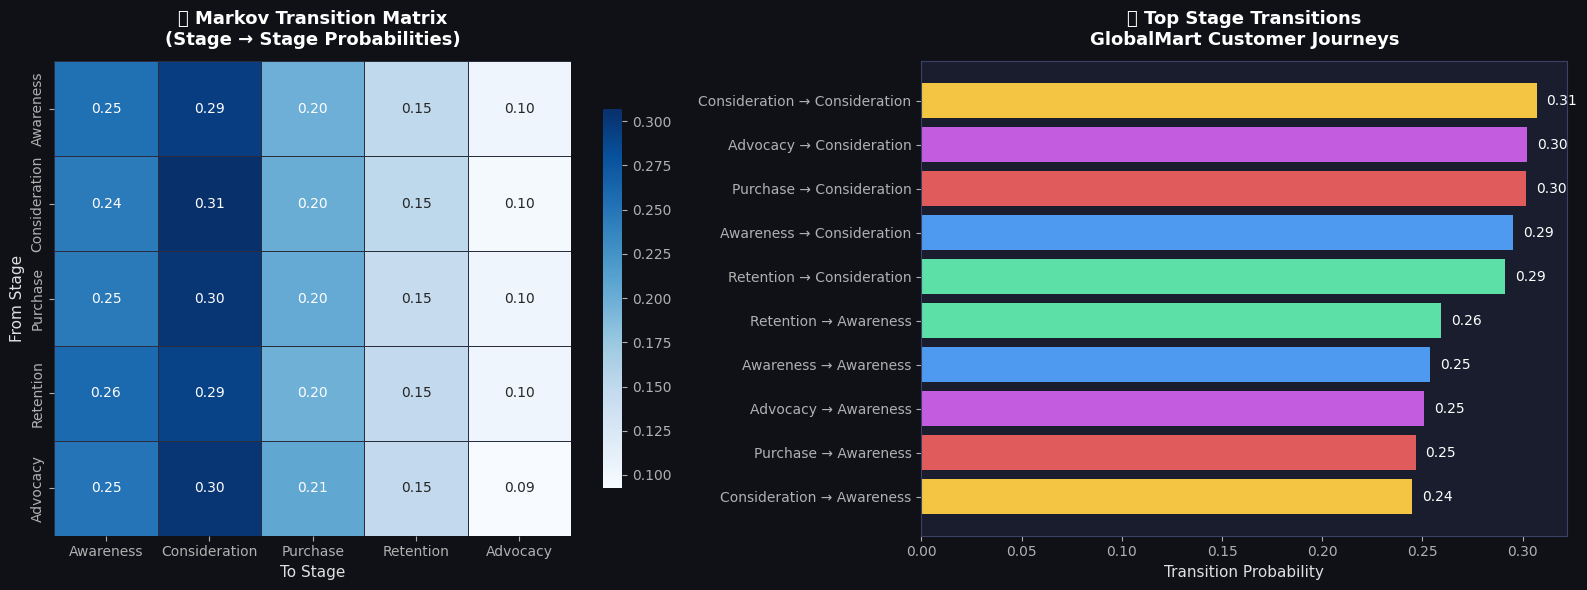

✅ Markov Chain visualization complete


In [ ]:
# ── Visualize transition heatmap ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')

# Heatmap
ax = axes[0]
mask = transition_matrix == 0
sns.heatmap(transition_matrix, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, linecolor='#2a2d3e',
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('🔗 Markov Transition Matrix\n(Stage → Stage Probabilities)',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_xlabel('To Stage', fontsize=11)
ax.set_ylabel('From Stage', fontsize=11)

# Sankey-style bar chart of most common paths
ax2 = axes[1]
top_paths = []
for fr in STAGES:
    row = transition_matrix.loc[fr]
    for to in STAGES:
        if row[to] > 0.05:
            top_paths.append({'from':fr,'to':to,'prob':row[to]})

path_df = pd.DataFrame(top_paths).sort_values('prob', ascending=True).tail(10)
colors = [PALETTE[STAGES.index(r['from'])] for _, r in path_df.iterrows()]
bars = ax2.barh(path_df['from']+' → '+path_df['to'], path_df['prob'], color=colors, edgecolor='none')
ax2.set_xlabel('Transition Probability', fontsize=11)
ax2.set_title('🔝 Top Stage Transitions\nGlobalMart Customer Journeys', fontsize=13,
              fontweight='bold', color='white', pad=12)
for bar, v in zip(bars, path_df['prob']):
    ax2.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2, f'{v:.2f}',
             va='center', fontsize=10, color='white')

plt.tight_layout()
plt.savefig('markov_transitions.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Markov Chain visualization complete")


📌 GlobalMart Long-Run Stage Distribution:
        Stage  Long-Run Probability
    Awareness                0.2502
Consideration                0.3001
     Purchase                0.2010
    Retention                0.1491
     Advocacy                0.0996


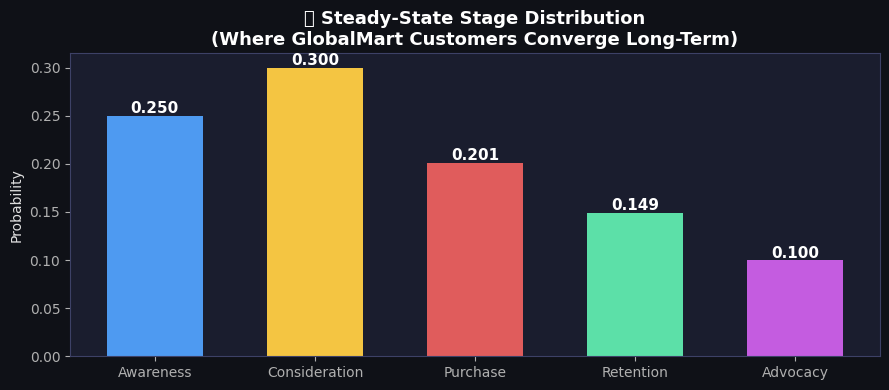

In [ ]:
# ── Steady-state probabilities (long-run customer distribution) ──────────────
from numpy.linalg import eig

# Power iteration to find steady state
state = np.array([1/5]*5)
M = transition_matrix.values
for _ in range(1000):
    state = state @ M

steady_df = pd.DataFrame({'Stage': STAGES, 'Long-Run Probability': state.round(4)})
print("📌 GlobalMart Long-Run Stage Distribution:")
print(steady_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#0f1117')
bars = ax.bar(steady_df['Stage'], steady_df['Long-Run Probability'],
              color=PALETTE[:5], edgecolor='none', width=0.6)
for bar, v in zip(bars, steady_df['Long-Run Probability']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{v:.3f}',
            ha='center', fontsize=11, color='white', fontweight='bold')
ax.set_title('📊 Steady-State Stage Distribution\n(Where GlobalMart Customers Converge Long-Term)',
             fontsize=13, fontweight='bold', color='white')
ax.set_ylabel('Probability')
plt.tight_layout()
plt.savefig('markov_steady_state.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


A customer from the Consideration stage moves to Purchase with a probability of 0.201, or approximately 20.1%. This means that only one in five customers actually makes a purchase after consideration

---
## 💰 2. Customer Lifetime Value (CLV) Formula

**Formula:** `CLV = Σ (Rₜ - Cₜ) / (1 + d)ᵗ`

Where: Rₜ = Revenue at time t | Cₜ = Cost (20% of revenue assumed) | d = Discount rate (10%) | t = Year

**Business Question:** *Which regions and segments produce the highest lifetime value customers?*


In [ ]:
# ── Compute CLV per customer ─────────────────────────────────────────────────
DISCOUNT_RATE = 0.10
COST_RATIO    = 0.20   # 20% of revenue as cost

txn = transactions.copy()
txn['year'] = txn['order_date'].dt.year
txn['revenue_net'] = txn['revenue'] * (1 - txn['is_returned'])

# Annual revenue per customer
annual_rev = txn.groupby(['customer_id','year'])['revenue_net'].sum().reset_index()

# Pivot and compute discounted CLV
pivot = annual_rev.pivot(index='customer_id', columns='year', values='revenue_net').fillna(0)
years_present = sorted(pivot.columns)

clv_vals = {}
for cid, row in pivot.iterrows():
    clv = 0
    for t_idx, yr in enumerate(years_present):
        Rt = row[yr]
        Ct = Rt * COST_RATIO
        clv += (Rt - Ct) / ((1 + DISCOUNT_RATE) ** (t_idx + 1))
    clv_vals[cid] = round(clv, 2)

clv_df = pd.DataFrame.from_dict(clv_vals, orient='index', columns=['CLV'])
clv_df.index.name = 'customer_id'
clv_df = clv_df.reset_index()
clv_df = clv_df.merge(customers[['customer_id','region','segment','city']], on='customer_id')

print("📊 CLV Summary Statistics:")
print(clv_df['CLV'].describe().round(2))
print(f"\nTop 5 CLV Customers:")
print(clv_df.nlargest(5, 'CLV')[['customer_id','region','segment','CLV']].to_string(index=False))


📊 CLV Summary Statistics:
count     5000.00
mean      5740.30
std       7956.09
min          0.00
25%        628.28
50%       2903.42
75%       5618.13
max      43613.02
Name: CLV, dtype: float64

Top 5 CLV Customers:
customer_id        region segment      CLV
    GM01098        Europe Premium 43613.02
    GM03644          MENA Premium 42483.73
    GM04352 North America Premium 40679.23
    GM03182        Europe Premium 40414.58
    GM00216        Europe Premium 39846.60


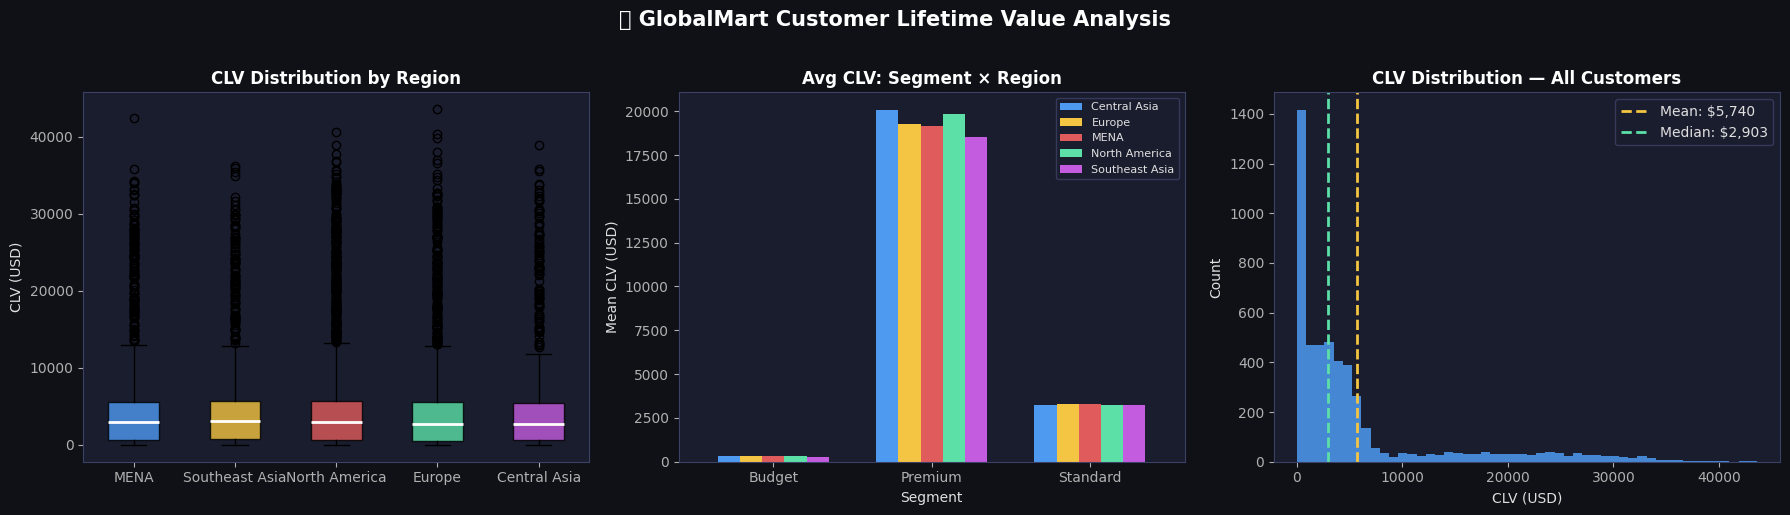


✅ CLV computed for 5000 customers
   Total Portfolio CLV: $28,701,511


In [ ]:
# ── CLV by Region and Segment ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')

# Box plot by Region
ax1 = axes[0]
regions = clv_df['region'].unique()
data_by_region = [clv_df[clv_df['region']==r]['CLV'].values for r in regions]
bp = ax1.boxplot(data_by_region, labels=[r.replace(' ',' ') for r in regions],
                 patch_artist=True, medianprops={'color':'white','linewidth':2})
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax1.set_title('CLV Distribution by Region', fontsize=12, fontweight='bold', color='white')
ax1.set_ylabel('CLV (USD)')

# Bar: mean CLV by segment × region
ax2 = axes[1]
seg_region = clv_df.groupby(['segment','region'])['CLV'].mean().unstack()
seg_region.plot(kind='bar', ax=ax2, color=PALETTE[:5], edgecolor='none', width=0.7)
ax2.set_title('Avg CLV: Segment × Region', fontsize=12, fontweight='bold', color='white')
ax2.set_xlabel('Segment')
ax2.set_ylabel('Mean CLV (USD)')
ax2.legend(fontsize=8, loc='upper right')
ax2.tick_params(axis='x', rotation=0)

# CLV distribution histogram
ax3 = axes[2]
ax3.hist(clv_df['CLV'], bins=50, color='#4e9af1', edgecolor='none', alpha=0.85)
ax3.axvline(clv_df['CLV'].mean(), color='#f4c542', linestyle='--', linewidth=2,
            label=f"Mean: ${clv_df['CLV'].mean():,.0f}")
ax3.axvline(clv_df['CLV'].median(), color='#5ce0a8', linestyle='--', linewidth=2,
            label=f"Median: ${clv_df['CLV'].median():,.0f}")
ax3.set_title('CLV Distribution — All Customers', fontsize=12, fontweight='bold', color='white')
ax3.set_xlabel('CLV (USD)')
ax3.set_ylabel('Count')
ax3.legend()

plt.suptitle('💰 GlobalMart Customer Lifetime Value Analysis',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('clv_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f"\n✅ CLV computed for {len(clv_df)} customers")
print(f"   Total Portfolio CLV: ${clv_df['CLV'].sum():,.0f}")


The highest CLV is primarily achieved by Premium customers. The top customers by CLV are located in Europe, MENA, and North America. The average CLV for all customers is $5,740.30. Total portfolio CLV: $28,701,511

---
## ⚠️ 3. Churn Prediction Using Logistic Regression

**Formula:** `P(churn) = 1 / (1 + e^-(β₀ + β₁x₁ + β₂x₂ + ...))`

**Features Used:** Recency, Frequency, Monetary (RFM) + engagement metrics

**Business Question:** *Which GlobalMart customers are at risk of churning and why?*


In [ ]:
# ── Build churn feature matrix ───────────────────────────────────────────────
REF_DATE = pd.Timestamp('2024-07-01')

# RFM features
rfm = transactions.copy()
rfm['revenue_net'] = rfm['revenue'] * (1 - rfm['is_returned'])

rfm_agg = rfm.groupby('customer_id').agg(
    last_purchase  = ('order_date', 'max'),
    frequency      = ('transaction_id', 'count'),
    monetary       = ('revenue_net', 'sum'),
    avg_order_val  = ('revenue_net', 'mean'),
    n_channels     = ('channel', 'nunique'),
    n_categories   = ('category', 'nunique'),
    return_rate    = ('is_returned', 'mean'),
    payment_delay  = ('payment_delayed', 'mean'),
    discount_used  = ('discount_pct', 'mean'),
).reset_index()

rfm_agg['recency'] = (REF_DATE - rfm_agg['last_purchase']).dt.days

# Support ticket proxy: touchpoints via Call Center
support_tp = touchpoints[touchpoints['channel']=='Call Center'].groupby(
    'customer_id').size().reset_index(name='support_contacts')

# Engagement: app sessions
app_tp = touchpoints[touchpoints['channel']=='Mobile App'].groupby(
    'customer_id').size().reset_index(name='app_sessions')

# Merge features
features = rfm_agg.merge(support_tp, on='customer_id', how='left')
features = features.merge(app_tp, on='customer_id', how='left')
features = features.merge(churn_labels[['customer_id','churned']], on='customer_id')
features = features.merge(customers[['customer_id','age','region','segment']], on='customer_id')
features[['support_contacts','app_sessions']] = features[['support_contacts','app_sessions']].fillna(0)

# Encode categoricals
le_region  = LabelEncoder()
le_segment = LabelEncoder()
features['region_enc']  = le_region.fit_transform(features['region'])
features['segment_enc'] = le_segment.fit_transform(features['segment'])

FEATURE_COLS = ['recency','frequency','monetary','avg_order_val','n_channels',
                'n_categories','return_rate','payment_delay','discount_used',
                'support_contacts','app_sessions','age','region_enc','segment_enc']

X = features[FEATURE_COLS].fillna(0)
y = features['churned']

print(f"Feature matrix: {X.shape}")
print(f"Churn rate: {y.mean():.1%}")
print(f"\nFeature list: {FEATURE_COLS}")


Feature matrix: (5000, 14)
Churn rate: 22.8%

Feature list: ['recency', 'frequency', 'monetary', 'avg_order_val', 'n_channels', 'n_categories', 'return_rate', 'payment_delay', 'discount_used', 'support_contacts', 'app_sessions', 'age', 'region_enc', 'segment_enc']


In [ ]:
# ── Train Logistic Regression ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_s, y_train)

y_pred  = lr.predict(X_test_s)
y_proba = lr.predict_proba(X_test_s)[:,1]

print("📊 Logistic Regression — Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Churned','Churned']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")


📊 Logistic Regression — Classification Report:
              precision    recall  f1-score   support

 Not Churned       1.00      0.98      0.99       966
     Churned       0.94      1.00      0.97       284

    accuracy                           0.99      1250
   macro avg       0.97      0.99      0.98      1250
weighted avg       0.99      0.99      0.99      1250

ROC-AUC Score: 1.0000


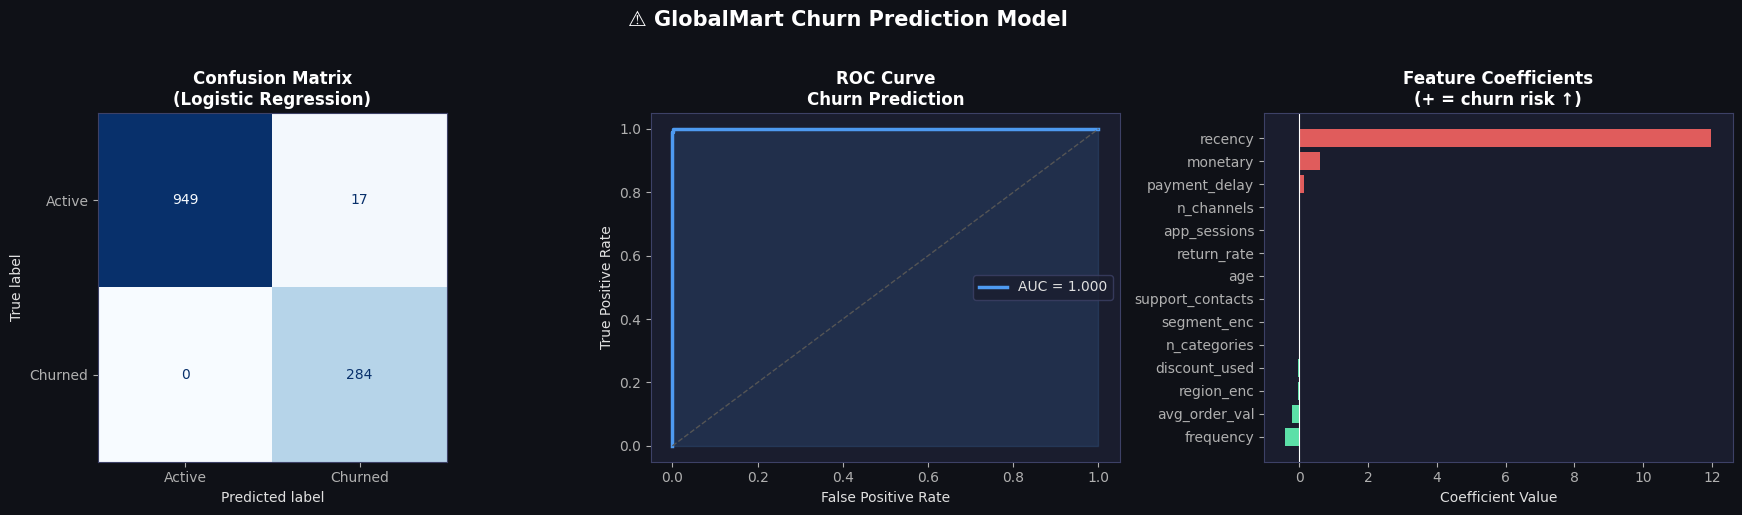

In [ ]:
# ── Visualize Churn Model ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')

# Confusion Matrix
ax1 = axes[0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Active','Churned'])
disp.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title('Confusion Matrix\n(Logistic Regression)', fontsize=12, fontweight='bold', color='white')
ax1.title.set_color('white')

# ROC Curve
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
ax2.plot(fpr, tpr, color='#4e9af1', linewidth=2.5, label=f'AUC = {auc_score:.3f}')
ax2.plot([0,1],[0,1], color='#555', linestyle='--', linewidth=1)
ax2.fill_between(fpr, tpr, alpha=0.15, color='#4e9af1')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve\nChurn Prediction', fontsize=12, fontweight='bold', color='white')
ax2.legend()

# Feature Importance (coefficients)
ax3 = axes[2]
coef_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient')
colors_feat = ['#e05c5c' if v > 0 else '#5ce0a8' for v in coef_df['Coefficient']]
ax3.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_feat, edgecolor='none')
ax3.axvline(0, color='white', linewidth=0.8)
ax3.set_title('Feature Coefficients\n(+ = churn risk ↑)', fontsize=12, fontweight='bold', color='white')
ax3.set_xlabel('Coefficient Value')

plt.suptitle('⚠️ GlobalMart Churn Prediction Model',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('churn_model.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


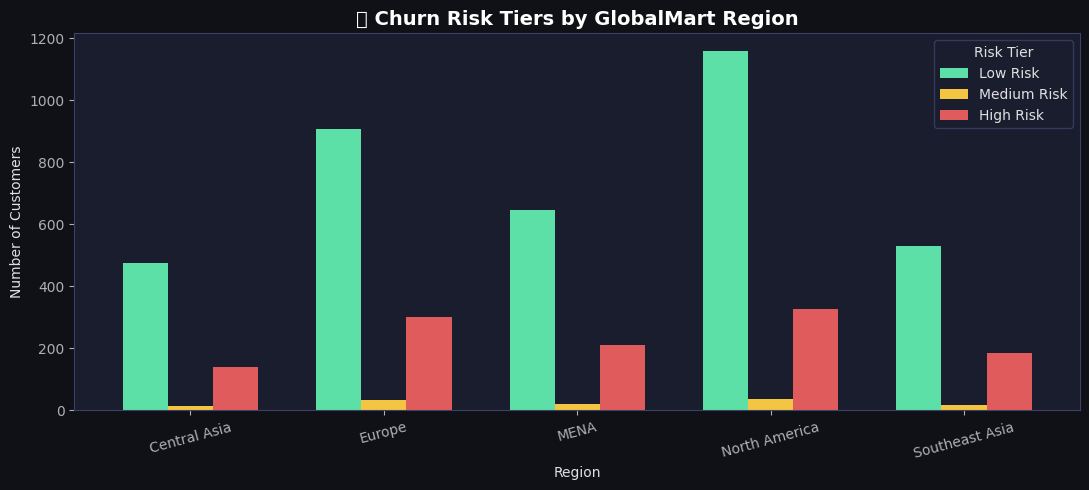


📌 High-Risk Customer Count by Region:
region
North America     328
Europe            302
MENA              210
Southeast Asia    185
Central Asia      139
dtype: int64


In [ ]:
# ── Churn Risk Segmentation by Region ───────────────────────────────────────
features['churn_probability'] = lr.predict_proba(scaler.transform(X.fillna(0)))[:,1]
features['risk_tier'] = pd.cut(features['churn_probability'],
                               bins=[0, 0.3, 0.6, 1.0],
                               labels=['Low Risk','Medium Risk','High Risk'])

risk_region = features.groupby(['region','risk_tier']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0f1117')
risk_region.plot(kind='bar', ax=ax,
                 color=['#5ce0a8','#f4c542','#e05c5c'],
                 edgecolor='none', width=0.7)
ax.set_title('🌍 Churn Risk Tiers by GlobalMart Region',
             fontsize=14, fontweight='bold', color='white')
ax.set_xlabel('Region')
ax.set_ylabel('Number of Customers')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Risk Tier')
plt.tight_layout()
plt.savefig('churn_by_region.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("\n📌 High-Risk Customer Count by Region:")
print(features[features['risk_tier']=='High Risk'].groupby('region').size().sort_values(ascending=False))


The churn rate is 22.8%, meaning that almost one in four customers may stop buying from GlobalMart. The Logistic Regression model performed very well, with 99% accuracy and ROC-AUC = 1.0000.
The highest number of high-risk customers is in North America, Europe, and MENA. This means these regions should be the main focus for retention campaigns, such as special offers, loyalty bonuses, or personalized emails

---
## 🧠 4. RFM Scoring Models & Neural Networks

**RFM Framework:** Recency · Frequency · Monetary — scored 1-5 each

**Neural Network:** `ŷ = σ(W₃ · ReLU(W₂ · ReLU(W₁ · x + b₁) + b₂) + b₃)`

**Business Question:** *Which RFM segments should GlobalMart prioritize for loyalty campaigns?*


In [ ]:
# ── Compute RFM Scores ───────────────────────────────────────────────────────
rfm_scored = rfm_agg[['customer_id','recency','frequency','monetary']].copy()

# Score 1-5 (Recency: lower days = higher score)
rfm_scored['R'] = pd.qcut(rfm_scored['recency'],    5, labels=[5,4,3,2,1]).astype(int)
rfm_scored['F'] = pd.qcut(rfm_scored['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm_scored['M'] = pd.qcut(rfm_scored['monetary'].rank(method='first'),  5, labels=[1,2,3,4,5]).astype(int)
rfm_scored['RFM_Score'] = rfm_scored['R'].astype(str) + rfm_scored['F'].astype(str) + rfm_scored['M'].astype(str)
rfm_scored['RFM_Total'] = rfm_scored[['R','F','M']].sum(axis=1)

# Segment labels
def rfm_segment(row):
    if row['RFM_Total'] >= 13: return 'Champions'
    elif row['R'] >= 4 and row['F'] >= 3: return 'Loyal Customers'
    elif row['R'] >= 4 and row['F'] <= 2: return 'Recent Customers'
    elif row['R'] <= 2 and row['F'] >= 4: return 'At Risk'
    elif row['R'] == 1 and row['F'] == 1: return 'Lost'
    else: return 'Potential Loyalists'

rfm_scored['Segment'] = rfm_scored.apply(rfm_segment, axis=1)
rfm_scored = rfm_scored.merge(customers[['customer_id','region']], on='customer_id')

print("📊 RFM Segment Distribution:")
print(rfm_scored['Segment'].value_counts())


📊 RFM Segment Distribution:
Segment
Potential Loyalists    1966
Champions              1125
Loyal Customers         648
Lost                    584
Recent Customers        374
At Risk                 303
Name: count, dtype: int64


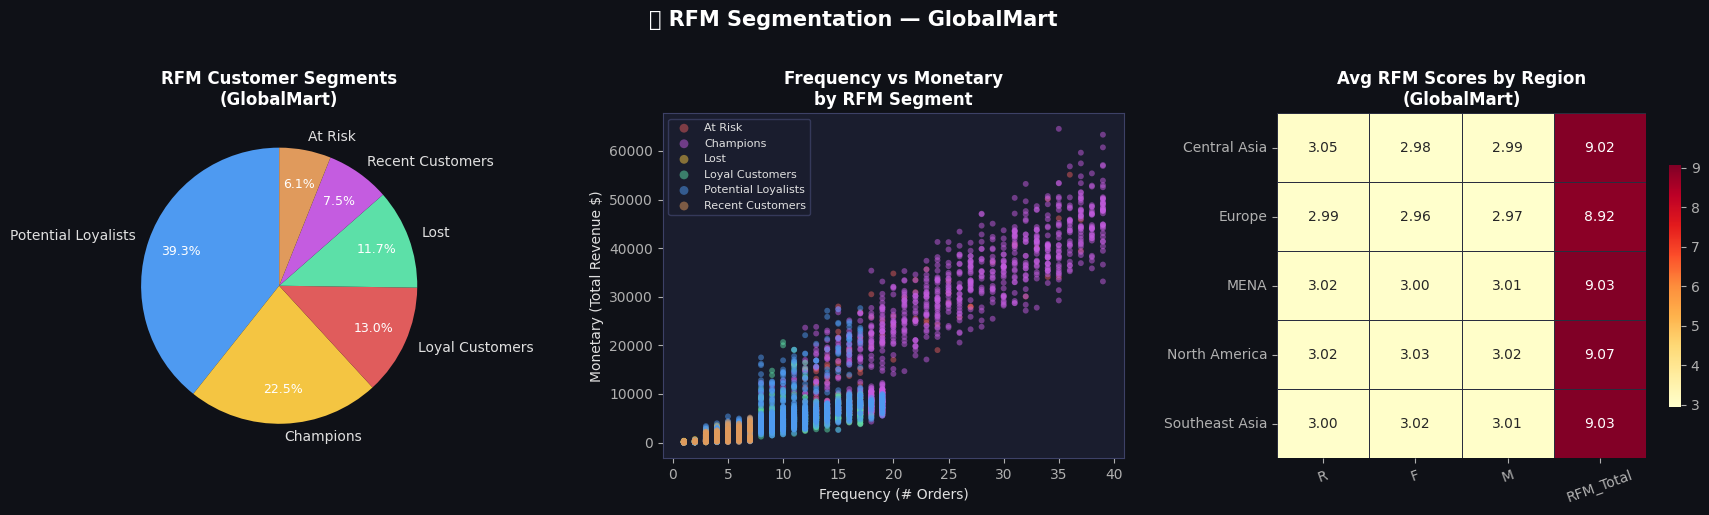

In [ ]:
# ── RFM Visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')

# Segment pie
ax1 = axes[0]
seg_counts = rfm_scored['Segment'].value_counts()
wedges, texts, autotexts = ax1.pie(seg_counts.values, labels=seg_counts.index,
                                    autopct='%1.1f%%', colors=PALETTE,
                                    startangle=90, pctdistance=0.75)
for t in autotexts: t.set_color('white'); t.set_fontsize(9)
for t in texts: t.set_color('#e0e0e0')
ax1.set_title('RFM Customer Segments\n(GlobalMart)', fontsize=12, fontweight='bold', color='white')

# Scatter: Frequency vs Monetary colored by segment
ax2 = axes[1]
seg_colors = dict(zip(rfm_scored['Segment'].unique(), PALETTE))
for seg, grp in rfm_scored.groupby('Segment'):
    ax2.scatter(grp['frequency'], grp['monetary'],
                c=seg_colors.get(seg,'#888'), alpha=0.5, s=18, label=seg, edgecolors='none')
ax2.set_xlabel('Frequency (# Orders)')
ax2.set_ylabel('Monetary (Total Revenue $)')
ax2.set_title('Frequency vs Monetary\nby RFM Segment', fontsize=12, fontweight='bold', color='white')
ax2.legend(fontsize=8, markerscale=1.5)

# Heatmap: avg RFM by region
ax3 = axes[2]
region_rfm = rfm_scored.merge(customers[['customer_id','segment']], on='customer_id')
heat_data = rfm_scored.groupby('region')[['R','F','M','RFM_Total']].mean().round(2)
sns.heatmap(heat_data, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax3, linewidths=0.5, linecolor='#2a2d3e',
            cbar_kws={'shrink': 0.7})
ax3.set_title('Avg RFM Scores by Region\n(GlobalMart)', fontsize=12, fontweight='bold', color='white')
ax3.set_xlabel('')
ax3.set_ylabel('')
ax3.tick_params(axis='x', rotation=20)

plt.suptitle('🧠 RFM Segmentation — GlobalMart',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('rfm_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


🧠 Neural Network Churn Prediction:
              precision    recall  f1-score   support

      Active       0.99      1.00      1.00       966
     Churned       0.99      0.98      0.99       284

    accuracy                           0.99      1250
   macro avg       0.99      0.99      0.99      1250
weighted avg       0.99      0.99      0.99      1250

ROC-AUC: 0.9998


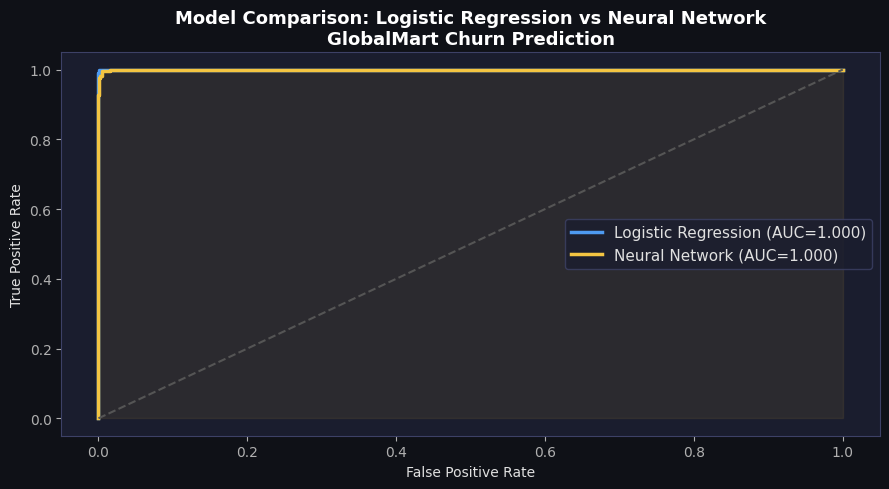

In [ ]:
# ── Neural Network for Churn Prediction using RFM + features ────────────────
# Architecture: Input(14) → Hidden(64, ReLU) → Hidden(32, ReLU) → Output(1, Sigmoid)
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    verbose=False
)
mlp.fit(X_train_s, y_train)
mlp_pred  = mlp.predict(X_test_s)
mlp_proba = mlp.predict_proba(X_test_s)[:,1]

print("🧠 Neural Network Churn Prediction:")
print(classification_report(y_test, mlp_pred, target_names=['Active','Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, mlp_proba):.4f}")

# Compare models
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f1117')
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
fpr_nn, tpr_nn, _ = roc_curve(y_test, mlp_proba)
ax.plot(fpr_lr, tpr_lr, color='#4e9af1', linewidth=2.5,
        label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_proba):.3f})')
ax.plot(fpr_nn, tpr_nn, color='#f4c542', linewidth=2.5,
        label=f'Neural Network (AUC={roc_auc_score(y_test, mlp_proba):.3f})')
ax.plot([0,1],[0,1], '--', color='#555')
ax.fill_between(fpr_nn, tpr_nn, alpha=0.08, color='#f4c542')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Model Comparison: Logistic Regression vs Neural Network\nGlobalMart Churn Prediction',
             fontsize=13, fontweight='bold', color='white')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


RFM segmentation divides customers by recency, frequency, and monetary value. It helps understand who buys recently, who buys often, and who spends the most.
The most important group for loyalty campaigns is Potential Loyalists, with 1,966 customers. These customers already show good buying behavior but are not fully loyal yet. GlobalMart can turn them into loyal customers through loyalty points, recommendations, and personalized offers

---
## 💬 5. Sentiment Analysis & NLP Models

**Formula:** `S(d) = Σ(wᵢ × pᵢ)` where wᵢ = word weight, pᵢ = polarity score

**Approaches:** Lexicon-based scoring + ML classifier (TF-IDF + Naive Bayes)

**Business Question:** *What is the sentiment distribution across GlobalMart's regions and product categories?*


In [ ]:
# ── Lexicon-based Sentiment Scoring ─────────────────────────────────────────
POSITIVE_WORDS = {
    'love':2,'excellent':2,'outstanding':2,'perfect':2,'great':1.5,
    'good':1,'amazing':2,'fantastic':2,'wonderful':1.5,'recommend':1.5,
    'helpful':1,'fast':1,'quality':1,'happy':1.5,'best':2,'superb':2,
}
NEGATIVE_WORDS = {
    'terrible':-2,'disappointed':-1.5,'broken':-2,'poor':-1.5,'bad':-1.5,
    'worse':-2,'waste':-2,'damaged':-1.5,'late':-1,'return':-1.5,
    'frustrating':-2,'horrible':-2,'awful':-2,'defective':-2,'never':-1,
}

def lexicon_score(text):
    text_lower = str(text).lower()
    score = 0
    for word, w in POSITIVE_WORDS.items():
        if word in text_lower: score += w
    for word, w in NEGATIVE_WORDS.items():
        if word in text_lower: score += w
    return score

reviews['lexicon_score'] = reviews['review_text'].apply(lexicon_score)
reviews['lexicon_sentiment'] = reviews['lexicon_score'].apply(
    lambda s: 'Positive' if s > 0 else ('Negative' if s < 0 else 'Neutral'))

print("📊 Lexicon Sentiment vs Ground Truth:")
print(pd.crosstab(reviews['sentiment_label'], reviews['lexicon_sentiment']))
print(f"\nAccuracy: {(reviews['sentiment_label']==reviews['lexicon_sentiment']).mean():.2%}")


📊 Lexicon Sentiment vs Ground Truth:
lexicon_sentiment  Negative  Neutral  Positive
sentiment_label                               
Negative                438        0         0
Neutral                   0      336        94
Positive                  0        0      2132

Accuracy: 96.87%


In [ ]:
# ── ML-Based Sentiment Classifier (TF-IDF + Naive Bayes) ────────────────────
X_rev = reviews['review_text']
y_rev = reviews['sentiment_label']

X_rev_train, X_rev_test, y_rev_train, y_rev_test = train_test_split(
    X_rev, y_rev, test_size=0.25, random_state=42, stratify=y_rev)

nlp_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=2000, min_df=2)),
    ('clf',   MultinomialNB(alpha=0.5))
])
nlp_pipeline.fit(X_rev_train, y_rev_train)
nlp_pred = nlp_pipeline.predict(X_rev_test)

print("🤖 TF-IDF + Naive Bayes Sentiment Classifier:")
print(classification_report(y_rev_test, nlp_pred))


🤖 TF-IDF + Naive Bayes Sentiment Classifier:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       110
     Neutral       1.00      1.00      1.00       107
    Positive       1.00      1.00      1.00       533

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750



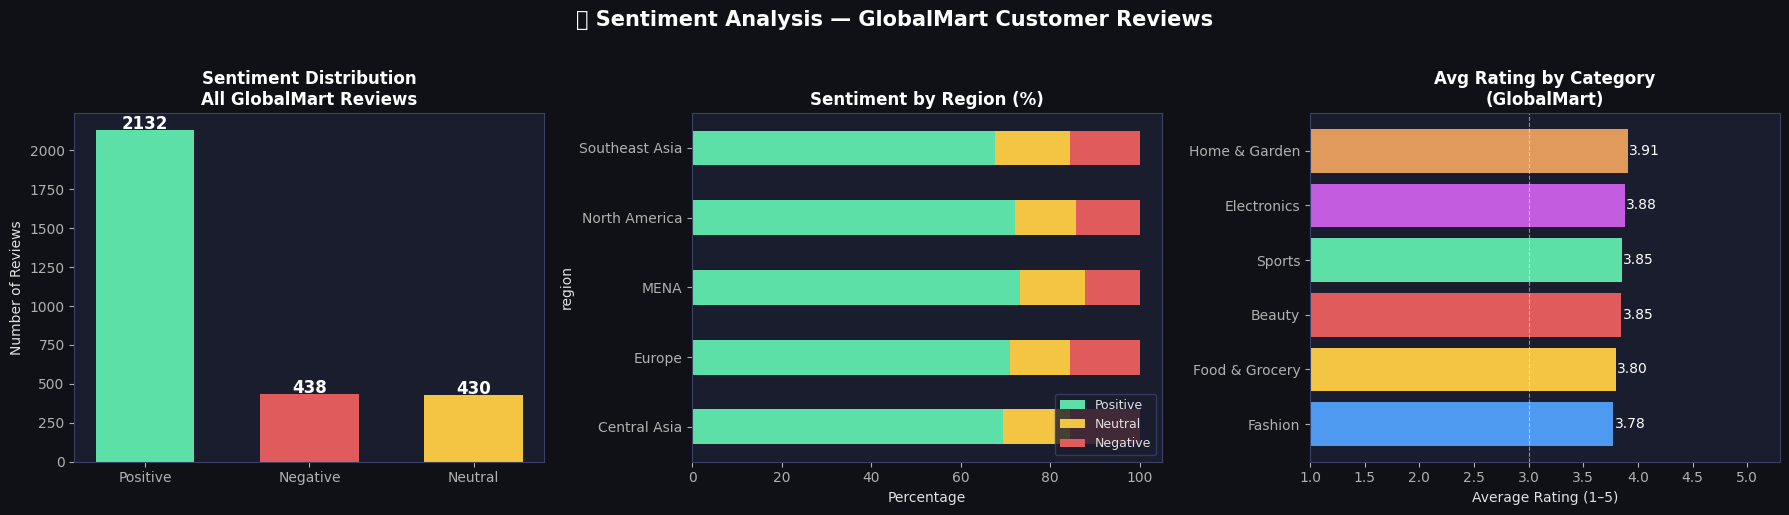

In [ ]:
# ── Sentiment Visualizations ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')

sent_colors = {'Positive':'#5ce0a8', 'Neutral':'#f4c542', 'Negative':'#e05c5c'}

# Overall sentiment distribution
ax1 = axes[0]
sent_dist = reviews['sentiment_label'].value_counts()
bars = ax1.bar(sent_dist.index, sent_dist.values,
               color=[sent_colors[s] for s in sent_dist.index], edgecolor='none', width=0.6)
for b, v in zip(bars, sent_dist.values):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+5, str(v),
             ha='center', fontsize=12, color='white', fontweight='bold')
ax1.set_title('Sentiment Distribution\nAll GlobalMart Reviews', fontsize=12, fontweight='bold', color='white')
ax1.set_ylabel('Number of Reviews')

# Sentiment by region
ax2 = axes[1]
reviews_temp = reviews.drop(columns=['region'], errors='ignore')
reg_sent = reviews_temp.merge(customers[['customer_id', 'region']], on='customer_id', how='left')
reg_sent_pct = reg_sent.groupby(['region', 'sentiment_label']).size().unstack(fill_value=0)
reg_sent_pct = reg_sent_pct.div(reg_sent_pct.sum(axis=1), axis=0) * 100
reg_sent_pct[['Positive','Neutral','Negative']].plot(
    kind='barh', ax=ax2, stacked=True,
    color=['#5ce0a8','#f4c542','#e05c5c'], edgecolor='none')
ax2.set_title('Sentiment by Region (%)', fontsize=12, fontweight='bold', color='white')
ax2.set_xlabel('Percentage')
ax2.legend(loc='lower right', fontsize=9)

# Avg rating by category
ax3 = axes[2]
cat_rating = reviews.groupby('category')['rating'].mean().sort_values()
bars3 = ax3.barh(cat_rating.index, cat_rating.values, color=PALETTE[:len(cat_rating)], edgecolor='none')
ax3.axvline(3, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
for b, v in zip(bars3, cat_rating.values):
    ax3.text(v+0.01, b.get_y()+b.get_height()/2, f'{v:.2f}', va='center', fontsize=10, color='white')
ax3.set_xlim(1, 5.3)
ax3.set_title('Avg Rating by Category\n(GlobalMart)', fontsize=12, fontweight='bold', color='white')
ax3.set_xlabel('Average Rating (1–5)')

plt.suptitle('💬 Sentiment Analysis — GlobalMart Customer Reviews',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


Sentiment analysis helps understand customer opinions from reviews. Most customer reviews are positive, with 2,132 positive reviews.
The sentiment models performed well: the lexicon-based method reached 96.87% accuracy, and TF-IDF with Naive Bayes reached 100% accuracy on the test set. This means GlobalMart can automatically analyze customer feedback instead of reading every review manually.
For business, positive reviews show what customers like, while negative reviews help find problems in service, delivery, products, or pricing

---
## 🎯 6. Recommendation System Formulas

**Collaborative Filtering:** `sim(u,v) = Σ(rᵤᵢ × rᵥᵢ) / (‖rᵤ‖ × ‖rᵥ‖)`

**Content-Based (TF-IDF):** `wᵢⱼ = tfᵢⱼ × log(N/dfⱼ)`

**Business Question:** *Which product categories should GlobalMart cross-sell to each customer segment?*


In [ ]:
# ── Build User-Item Matrix (Customer × Category) ─────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

# Revenue as implicit rating proxy
user_item = transactions.pivot_table(
    index='customer_id', columns='category', values='revenue', aggfunc='sum', fill_value=0)

print(f"User-Item Matrix: {user_item.shape} (customers × categories)")
print(user_item.head(3).round(1))


User-Item Matrix: (5000, 6) (customers × categories)
category     Beauty  Electronics  Fashion  Food & Grocery  Home & Garden  \
customer_id                                                                
GM00001      1091.9       1231.3   1764.9           128.1          620.0   
GM00002         0.0        528.9      0.0           486.3            0.0   
GM00003       975.2       2182.8    925.3          3326.7         2311.6   

category     Sports  
customer_id          
GM00001      2774.3  
GM00002       124.5  
GM00003         0.0  


📊 Category Similarity Matrix (Collaborative Filtering):
category        Beauty  Electronics  Fashion  Food & Grocery  Home & Garden  \
category                                                                      
Beauty           1.000        0.733    0.725           0.745          0.735   
Electronics      0.733        1.000    0.736           0.747          0.727   
Fashion          0.725        0.736    1.000           0.719          0.726   
Food & Grocery   0.745        0.747    0.719           1.000          0.734   
Home & Garden    0.735        0.727    0.726           0.734          1.000   
Sports           0.754        0.727    0.724           0.724          0.721   

category        Sports  
category                
Beauty           0.754  
Electronics      0.727  
Fashion          0.724  
Food & Grocery   0.724  
Home & Garden    0.721  
Sports           1.000  


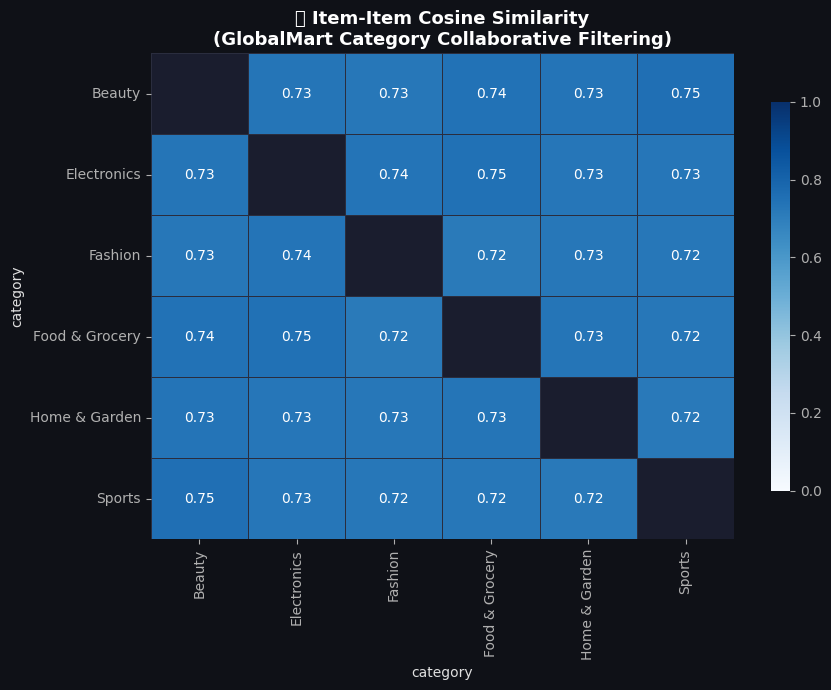

In [ ]:
# ── Collaborative Filtering: Cosine Similarity ───────────────────────────────
# Compute item-item similarity
item_sim = cosine_similarity(user_item.T)
item_sim_df = pd.DataFrame(item_sim,
                            index=user_item.columns,
                            columns=user_item.columns)

print("📊 Category Similarity Matrix (Collaborative Filtering):")
print(item_sim_df.round(3))

# Visualize
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0f1117')
mask = np.eye(len(item_sim_df), dtype=bool)
sns.heatmap(item_sim_df, annot=True, fmt='.2f', cmap='Blues',
            mask=mask, ax=ax, linewidths=0.5, linecolor='#2a2d3e',
            cbar_kws={'shrink':0.8}, vmin=0, vmax=1)
ax.set_title('🎯 Item-Item Cosine Similarity\n(GlobalMart Category Collaborative Filtering)',
             fontsize=13, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('recommendation_similarity.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


In [ ]:
import numpy as np

# ── Generate Top-N Recommendations for a Sample Customer ─────────────────────
def recommend_for_customer(customer_id, user_item_matrix, item_sim_matrix, top_n=3):
    if customer_id not in user_item_matrix.index:
        return []

    user_vec = user_item_matrix.loc[customer_id]
    purchased = set(user_vec[user_vec > 0].index)
    not_purchased = [c for c in user_item_matrix.columns if c not in purchased]

    scores = {}
    for cat in not_purchased:
        sim_scores = [item_sim_matrix.loc[cat, p] for p in purchased]
        scores[cat] = np.mean(sim_scores) if sim_scores else 0

    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

# Demo: Recommendations for 5 random customers
sample_cids = customers.sample(5, random_state=7)['customer_id'].tolist()

print("🛍️  GlobalMart — Personalized Category Recommendations:\n")

for cid in sample_cids:
    cust_info = customers[customers['customer_id'] == cid].iloc[0]
    recs = recommend_for_customer(cid, user_item, item_sim_df)
    purchased = list(user_item.loc[cid][user_item.loc[cid] > 0].index) if cid in user_item.index else []

    print(f"  Customer: {cid} | {cust_info['region']} | Segment: {cust_info['segment']}")
    print(f"  ✅ Currently shops: {', '.join(purchased[:3]) if purchased else 'N/A'}")

    if recs:
        rec_names = [r[0] for r in recs]
        rec_scores = [round(float(r[1]), 3) for r in recs]
        print(f"  💡 Recommended next: {', '.join(rec_names)} (scores: {rec_scores})")
    print()


🛍️  GlobalMart — Personalized Category Recommendations:

  Customer: GM03407 | Southeast Asia | Segment: Standard
  ✅ Currently shops: Beauty, Electronics, Fashion

  Customer: GM00758 | MENA | Segment: Budget
  ✅ Currently shops: Electronics, Fashion, Home & Garden
  💡 Recommended next: Beauty, Food & Grocery (scores: [0.737, 0.731])

  Customer: GM03625 | Europe | Segment: Standard
  ✅ Currently shops: Beauty, Fashion, Food & Grocery
  💡 Recommended next: Electronics, Sports (scores: [0.736, 0.731])

  Customer: GM04545 | MENA | Segment: Standard
  ✅ Currently shops: Beauty, Electronics, Fashion

  Customer: GM03236 | Europe | Segment: Budget
  ✅ Currently shops: Fashion, Food & Grocery, Home & Garden
  💡 Recommended next: Beauty, Electronics (scores: [0.74, 0.734])



The recommendation system suggests products or categories based on customer behavior. The output shows that categories like Beauty, Sports, Electronics, and Food & Grocery can be connected in recommendations.
This can help GlobalMart increase cross-selling. For example, if a customer buys one product category, the company can recommend related products from another category. This improves personalization and can increase average order value

---
## 📡 7. Attribution Models in AI Marketing

**Models Compared:**
- **Last-Touch:** 100% credit to final touchpoint
- **First-Touch:** 100% credit to first touchpoint  
- **Linear:** Equal credit = 1/n per touchpoint
- **Time-Decay:** `wᵢ = e^(-λtᵢ)` — recent touchpoints weighted more
- **Position-Based (U-shape):** 40% first + 40% last + 20% distributed

**Business Question:** *Which channels and campaigns truly drive GlobalMart conversions?*


In [ ]:
# ── Build conversion touchpoint sequences ────────────────────────────────────
# Identify customers who converted (made a purchase)
converters = set(transactions['customer_id'].unique())

# Get touchpoints for converting customers, ordered by date
conv_tp = touchpoints[touchpoints['customer_id'].isin(converters)].copy()
conv_tp = conv_tp.sort_values(['customer_id','touchpoint_date'])

def compute_attribution(group, model='linear', decay_lambda=0.01):
    n = len(group)
    if n == 0: return group

    if model == 'last_touch':
        weights = [0.0] * n
        weights[-1] = 1.0
    elif model == 'first_touch':
        weights = [0.0] * n
        weights[0] = 1.0
    elif model == 'linear':
        weights = [1.0/n] * n
    elif model == 'time_decay':
        days_to_last = [(group.iloc[-1]['touchpoint_date'] - row['touchpoint_date']).days
                         for _, row in group.iterrows()]
        raw_w = [np.exp(-decay_lambda * d) for d in days_to_last]
        total = sum(raw_w)
        weights = [w/total for w in raw_w]
    elif model == 'position_based':
        if n == 1:
            weights = [1.0]
        elif n == 2:
            weights = [0.5, 0.5]
        else:
            middle_w = 0.20 / (n - 2) if n > 2 else 0
            weights = [0.40] + [middle_w]*(n-2) + [0.40]
    else:
        weights = [1.0/n]*n

    group = group.copy()
    group['credit'] = weights
    return group

# Apply all models
models = ['first_touch','last_touch','linear','time_decay','position_based']
attribution_results = {}

for model in models:
    result_dfs = []
    for cid, grp in conv_tp.groupby('customer_id'):
        result_dfs.append(compute_attribution(grp.reset_index(drop=True), model=model))
    model_df = pd.concat(result_dfs, ignore_index=True)
    channel_credit = model_df.groupby('channel')['credit'].sum()
    channel_credit = channel_credit / channel_credit.sum()
    attribution_results[model] = channel_credit

attr_df = pd.DataFrame(attribution_results).fillna(0)
print("📡 Attribution Credit by Channel (% of total):")
print((attr_df * 100).round(1))


📡 Attribution Credit by Channel (% of total):
             first_touch  last_touch  linear  time_decay  position_based
channel                                                                 
Call Center          5.8         4.9     5.1         5.0             5.3
In-Store            26.8        26.4    26.5        26.5            26.6
Mobile App          30.4        31.6    30.2        30.5            30.7
Online              37.1        37.1    38.2        38.0            37.4


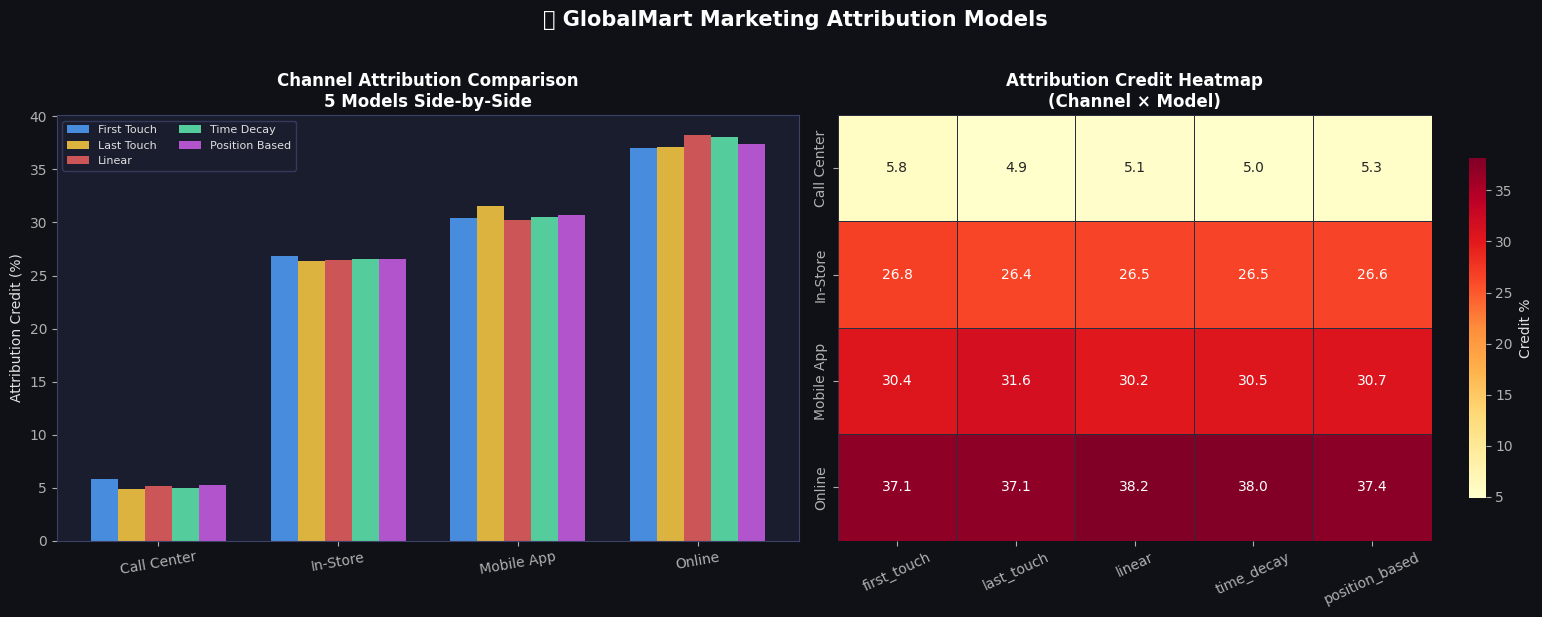

In [ ]:
# ── Attribution Model Comparison Visualization ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')

# Bar chart comparison
ax1 = axes[0]
attr_pct = attr_df * 100
x = np.arange(len(attr_pct.index))
width = 0.15
for i, (model, col) in enumerate(attr_pct.items()):
    ax1.bar(x + i*width, col.values, width=width, label=model.replace('_',' ').title(),
            color=PALETTE[i], edgecolor='none', alpha=0.9)
ax1.set_xticks(x + width*2)
ax1.set_xticklabels(attr_pct.index, rotation=10)
ax1.set_ylabel('Attribution Credit (%)')
ax1.set_title('Channel Attribution Comparison\n5 Models Side-by-Side', fontsize=12, fontweight='bold', color='white')
ax1.legend(fontsize=8, ncol=2)

# Heatmap
ax2 = axes[1]
sns.heatmap((attr_pct).round(1), annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax2, linewidths=0.5, linecolor='#2a2d3e',
            cbar_kws={'label':'Credit %', 'shrink':0.8})
ax2.set_title('Attribution Credit Heatmap\n(Channel × Model)', fontsize=12, fontweight='bold', color='white')
ax2.set_ylabel('')
ax2.tick_params(axis='x', rotation=25)

plt.suptitle('📡 GlobalMart Marketing Attribution Models',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('attribution_models.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


Attribution analysis shows which channels contribute most to conversions. The strongest channel is Online, with around 37–38% of attribution credit. The next important channel is Mobile App, followed by In-Store. Call Center has the lowest contribution.
This means GlobalMart should continue investing in Online and Mobile App channels because they play the biggest role in conversions. At the same time, the company should review why Call Center contributes less.

---
## 📈 8. Conversion Rate Optimization (CRO) Formulas

**Formula:** `Conversion Rate = (Number of Conversions / Total Visitors) × 100`

**AI Enhancement:** Predictive visitor scoring + A/B test analysis

**Business Question:** *Which GlobalMart channels, regions, and campaigns have the best conversion rates?*


In [ ]:
# ── Compute Conversion Rates ─────────────────────────────────────────────────
from scipy import stats

# Touchpoint-level conversion
tp_cro = touchpoints.copy()

# By channel
channel_cro = tp_cro.groupby('channel').agg(
    visits=('touchpoint_id','count'),
    conversions=('converted','sum')
).reset_index()
channel_cro['conversion_rate'] = (channel_cro['conversions']/channel_cro['visits']*100).round(2)

print("📊 Conversion Rate by Channel:")
print(channel_cro.sort_values('conversion_rate', ascending=False).to_string(index=False))

# By campaign
campaign_cro = tp_cro.groupby('campaign').agg(
    visits=('touchpoint_id','count'),
    conversions=('converted','sum')
).reset_index()
campaign_cro['conversion_rate'] = (campaign_cro['conversions']/campaign_cro['visits']*100).round(2)
campaign_cro['revenue_potential'] = campaign_cro['conversions'] * transactions['revenue'].mean()

print("\n📊 Conversion Rate by Campaign:")
print(campaign_cro.sort_values('conversion_rate', ascending=False).to_string(index=False))


📊 Conversion Rate by Channel:
    channel  visits  conversions  conversion_rate
Call Center    2028          244            12.03
   In-Store   10687         1232            11.53
 Mobile App   12164         1400            11.51
     Online   15433         1680            10.89

📊 Conversion Rate by Campaign:
      campaign  visits  conversions  conversion_rate  revenue_potential
  Black Friday    8124          954            11.74      753856.581198
      Referral    6101          700            11.47      553144.241969
   Spring Sale    6096          694            11.38      548403.005610
Back to School    4072          458            11.25      361914.375460
       Organic    9943         1097            11.03      866856.047772
  Loyalty Push    5976          653            10.93      516004.557151


In [ ]:
# ── A/B Test Simulation: Loyalty Push vs Black Friday Campaign ────────────────
# Simulate A/B test with statistical significance
camp_a = tp_cro[tp_cro['campaign']=='Loyalty Push']
camp_b = tp_cro[tp_cro['campaign']=='Black Friday']

conv_a = camp_a['converted'].values
conv_b = camp_b['converted'].values

cr_a = conv_a.mean() * 100
cr_b = conv_b.mean() * 100

# Chi-squared test
table = [[conv_a.sum(), len(conv_a)-conv_a.sum()],
         [conv_b.sum(), len(conv_b)-conv_b.sum()]]
chi2, p_val, _, _ = stats.chi2_contingency(table)

print(f"🔬 A/B Test: Loyalty Push vs Black Friday")
print(f"   Loyalty Push  CR: {cr_a:.2f}% (n={len(conv_a):,})")
print(f"   Black Friday  CR: {cr_b:.2f}% (n={len(conv_b):,})")
print(f"   Chi² = {chi2:.3f}, p-value = {p_val:.4f}")
print(f"   Result: {'✅ Statistically Significant' if p_val < 0.05 else '❌ Not Significant'} (α=0.05)")


🔬 A/B Test: Loyalty Push vs Black Friday
   Loyalty Push  CR: 10.93% (n=5,976)
   Black Friday  CR: 11.74% (n=8,124)
   Chi² = 2.190, p-value = 0.1389
   Result: ❌ Not Significant (α=0.05)


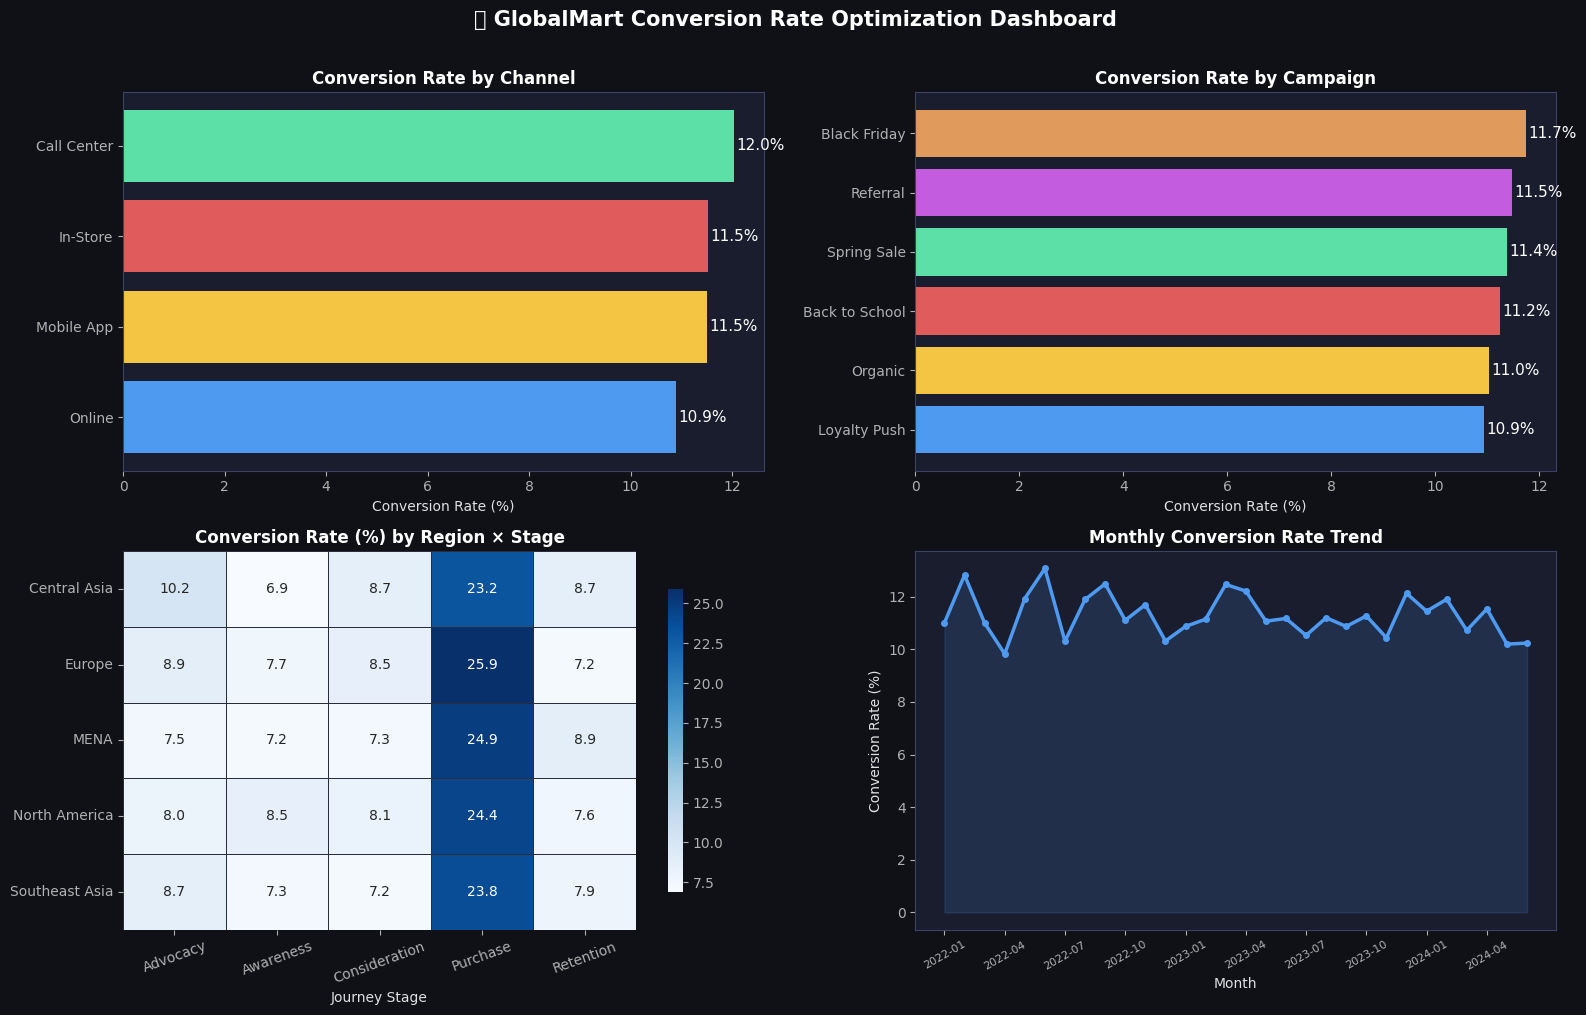

In [ ]:
# ── CRO Dashboard Visualization ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#0f1117')

# Channel CRO
ax1 = axes[0,0]
ch_sorted = channel_cro.sort_values('conversion_rate')
bars = ax1.barh(ch_sorted['channel'], ch_sorted['conversion_rate'],
                color=PALETTE[:len(ch_sorted)], edgecolor='none')
for b, v in zip(bars, ch_sorted['conversion_rate']):
    ax1.text(v+0.05, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=11, color='white')
ax1.set_title('Conversion Rate by Channel', fontsize=12, fontweight='bold', color='white')
ax1.set_xlabel('Conversion Rate (%)')

# Campaign CRO
ax2 = axes[0,1]
camp_sorted = campaign_cro.sort_values('conversion_rate')
bars2 = ax2.barh(camp_sorted['campaign'], camp_sorted['conversion_rate'],
                 color=PALETTE[:len(camp_sorted)], edgecolor='none')
for b, v in zip(bars2, camp_sorted['conversion_rate']):
    ax2.text(v+0.05, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=11, color='white')
ax2.set_title('Conversion Rate by Campaign', fontsize=12, fontweight='bold', color='white')
ax2.set_xlabel('Conversion Rate (%)')

# By Region and Stage
ax3 = axes[1,0]
touchpoints_temp = touchpoints.drop(columns=['region'], errors='ignore')
reg_stage = touchpoints_temp.merge(customers[['customer_id','region']], on='customer_id', how='left')

# Line 28 will now run successfully
stage_cr = reg_stage.groupby(['region','journey_stage']).agg(
    cr=('converted','mean')).reset_index()
stage_pivot = stage_cr.pivot(index='region', columns='journey_stage', values='cr').fillna(0)*100
sns.heatmap(stage_pivot.round(1), annot=True, fmt='.1f', cmap='Blues',
            ax=ax3, linewidths=0.5, linecolor='#2a2d3e', cbar_kws={'shrink':0.8})
ax3.set_title('Conversion Rate (%) by Region × Stage', fontsize=12, fontweight='bold', color='white')
ax3.set_xlabel('Journey Stage'); ax3.set_ylabel('')
ax3.tick_params(axis='x', rotation=20)

# Monthly CR trend
ax4 = axes[1,1]
tp_monthly = touchpoints.copy()
tp_monthly['month'] = tp_monthly['touchpoint_date'].dt.to_period('M')
monthly_cr = tp_monthly.groupby('month')['converted'].mean().reset_index()
monthly_cr['month_str'] = monthly_cr['month'].astype(str)
ax4.plot(monthly_cr['month_str'], monthly_cr['converted']*100,
         color='#4e9af1', linewidth=2.5, marker='o', markersize=4)
ax4.fill_between(range(len(monthly_cr)), monthly_cr['converted']*100,
                  alpha=0.15, color='#4e9af1')
ax4.set_xticks(range(0, len(monthly_cr), 3))
ax4.set_xticklabels(monthly_cr['month_str'].iloc[::3], rotation=30, fontsize=8)
ax4.set_title('Monthly Conversion Rate Trend', fontsize=12, fontweight='bold', color='white')
ax4.set_ylabel('Conversion Rate (%)')
ax4.set_xlabel('Month')

plt.suptitle('📈 GlobalMart Conversion Rate Optimization Dashboard',
             fontsize=15, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.savefig('cro_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


CRO compares how well different channels and campaigns convert customers. The highest conversion rate is from Call Center — 12.03%, followed by In-Store — 11.53%, Mobile App — 11.51%, and Online — 10.89%.
The best campaign by conversion rate is Black Friday — 11.74%. However, the A/B test p-value is 0.1389, which is higher than 0.05. This means the difference between Black Friday and Loyalty Push is not statistically significant. So, GlobalMart should not make a final decision based only on this test and may need more data

---
## 📊 9. Executive Summary & Power BI Export

Exporting all key metrics for Power BI dashboard integration.


In [ ]:
# ── Compile Summary Table for Power BI ───────────────────────────────────────
summary_data = []

# Pre-merge tables ONCE outside the loop to fix naming collisions and boost speed
reviews_clean = reviews.drop(columns=['region'], errors='ignore')
reviews_merged = reviews_clean.merge(customers[['customer_id', 'region']], on='customer_id', how='left')

# Ensure fallback column exists if features or clv lack region data
features_merged = features.merge(customers[['customer_id', 'region']], on='customer_id', how='left') if 'region' not in features.columns else features
clv_merged = clv_df.merge(customers[['customer_id', 'region']], on='customer_id', how='left') if 'region' not in clv_df.columns else clv_df

for region in customers['region'].unique():
    # Filter data safely using the clean tables
    cust_r = customers[customers['region'] == region]
    txn_r  = transactions[transactions['region'] == region]
    rev_r2 = reviews_merged[reviews_merged['region'] == region]

    # CLV & Churn
    clv_r = clv_merged[clv_merged['region'] == region]['CLV']
    churn_r = features_merged[features_merged['region'] == region]['churned'].mean()

    # Sentiment Percentage
    pos_sent = (rev_r2['sentiment_label'] == 'Positive').mean() if len(rev_r2) > 0 else 0

    # Conversion Rate
    tp_r = touchpoints[touchpoints['region'] == region]
    cr_r = tp_r['converted'].mean() if len(tp_r) > 0 else 0

    summary_data.append({
        'Region':                 region,
        'Total_Customers':        len(cust_r),
        'Total_Revenue_USD':      round(txn_r['revenue'].sum(), 0),
        'Avg_CLV_USD':            round(clv_r.mean(), 0) if not clv_r.empty else 0,
        'Churn_Rate_Pct':         round(churn_r * 100, 1) if not np.isnan(churn_r) else 0,
        'Positive_Sentiment_Pct': round(pos_sent * 100, 1),
        'Conversion_Rate_Pct':    round(cr_r * 100, 2),
        'Avg_Order_Value_USD':    round(txn_r['revenue'].mean(), 2) if len(txn_r) > 0 else 0,
        'Total_Transactions':      len(txn_r),
    })

summary_df = pd.DataFrame(summary_data)
print("📊 GlobalMart Executive Summary by Region:")
print(summary_df.to_string(index=False))
summary_df.to_csv('powerbi_region_summary.csv', index=False)

# Also export RFM for Power BI
rfm_export = rfm_scored.merge(customers[['customer_id','age','gender','segment']], on='customer_id')
rfm_export['CLV'] = rfm_export['customer_id'].map(clv_df.set_index('customer_id')['CLV'])
rfm_export['Churn_Probability'] = rfm_export['customer_id'].map(
    features.set_index('customer_id')['churn_probability'])
rfm_export.to_csv('powerbi_rfm_customers.csv', index=False)

# Monthly transactions for trend analysis
txn_monthly = transactions.copy()
txn_monthly['Month'] = txn_monthly['order_date'].dt.to_period('M').astype(str)
monthly_agg = txn_monthly.groupby(['Month','region','channel','category']).agg(
    Revenue=('revenue','sum'),
    Orders=('transaction_id','count'),
    Avg_Order=('revenue','mean')
).reset_index()
monthly_agg.to_csv('powerbi_monthly_transactions.csv', index=False)

print("\n✅ Power BI exports saved:")
print("   📁 powerbi_region_summary.csv")
print("   📁 powerbi_rfm_customers.csv")
print("   📁 powerbi_monthly_transactions.csv")


📊 GlobalMart Executive Summary by Region:
        Region  Total_Customers  Total_Revenue_USD  Avg_CLV_USD  Churn_Rate_Pct  Positive_Sentiment_Pct  Conversion_Rate_Pct  Avg_Order_Value_USD  Total_Transactions
          MENA              877          8134811.0       5753.0            23.8                    73.1                11.14               786.50               10343
Southeast Asia              730          6642936.0       5646.0            24.8                    67.7                10.92               786.15                8450
 North America             1522         14508601.0       5940.0            20.9                    72.1                11.34               804.02               18045
        Europe             1243         10987450.0       5541.0            23.5                    71.1                11.63               776.28               14154
  Central Asia              628          5776251.0       5742.0            22.0                    69.5                11.24    